# JOINT FITTING BETWEEN FERMI, VERITAS (IN GAMMAPY) AND HAWC FOR A POINT SOURCE WITH POWER LAW SPECTRUM USING CRAB DATA

Anjana Kaushik Talluri

Note: The code below relies on J. Michael's model converter 

# Import packages

In [1]:
import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")



import matplotlib.pyplot as plt

import astropy.units as u
from threeML import *
from threeML.io.package_data import get_path_of_data_file



import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")
import shutil
from IPython.display import Image, display
import glob
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt
from astropy.io import fits as pyfits
import scipy as sp


from threeML import *




12:56:31 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=413359;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=282921;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=708793;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=815483;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=277954;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=372394;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=691356;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=909764;file:///home/tobi/sw/threeML/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=743861;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=453416;file:///home/tobi/sw/threeML/threeML/__init__.py#40\40]8;;\

...

         WARNING    to disable these messages, turn off start_warning in your config file            ]8;id=966229;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=503060;file:///home/tobi/sw/threeML/threeML/__init__.py#44\44]8;;\

12:56:32 WARNING   ROOT minimizer not available                                                ]8;id=926115;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=853574;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py#1345\1345]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=835303;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=421914;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py#1369\1369]8;;\

12:56:32 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=565365;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=95674;file:///home/tobi/sw/threeML/threeML/__init__.py#94\94]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=403332;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=661736;file:///home/tobi/sw/threeML/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

In [2]:
from gammapy.datasets.map import MapDataset
from gammapy.datasets import Datasets
from gammapy.data.data_store import DataStore
from pathlib import Path

# Check package versions
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord
from regions import CircleSkyRegion

# %matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator
from gammapy.estimators.utils import resample_energy_edges
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    SkyModel,
    create_crab_spectral_model,
)
ds = DataStore.from_dir("/data/tobi/gammapy-datasets/dev/hess-dl3-dr1/")

In [3]:
from astromodels import Powerlaw

import astropy.units as u
import numpy as np

# Define a common model of a point source with a power law spectrum for all instruments for Crab

In [55]:
spectrum = Powerlaw()


spectrum.piv.value = 1
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K.value = 3.37e-20
#spectrum.K.unit = 1 / (u.keV * u.cm**2 * u.s)
spectrum.K.prior = Log_uniform_prior(lower_bound = 10e-30,upper_bound = 10e-3)
spectrum.K.min_value = 10e-50
#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index.value = -2.53
spectrum.index.prior = Uniform_prior(lower_bound = -5,upper_bound =-1)

source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)
#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [56]:

f_model = Model(source)
f_model.display()
#ene = np.array([1,10,100])



Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  keV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

# VERITAS

In [57]:
from gammapy_plugin.GammapyLike import GammapyLike

In [58]:
VERITAS = GammapyLike("VERITAS")

In [59]:
import yaml
with open("/home/tobi/sw/gammapy-plugin/examples/config.yaml","r") as f:
    config_file = yaml.safe_load(f)
data_dir = config_file['data']['anasum']
output_dir = config_file['fileio']['outdir']
on_region_radius = Angle(
    "{} deg".format(np.sqrt(config_file['cuts']['th2cut']))
)
emin = config_file['selection']['emin']
emax = config_file['selection']['emax']
nbin = config_file['selection']['nbin']
exclusion_on = config_file['selection']['exc_on_region_radius']
exc_radius = config_file['selection']['exc_radius']
datastore = DataStore.from_dir(data_dir)
obs_table = datastore.obs_table
obs_ids = obs_table['OBS_ID']
available_irf = ["aeff", "edisp"]
observations = datastore.get_observations(
    obs_ids, required_irf=available_irf
)
RA = obs_table['RA_OBJ']
DEC = obs_table['DEC_OBJ']
RA_OBJ = RA[0]
DEC_OBJ = DEC[0]
target_position = SkyCoord(
    ra=RA_OBJ, dec=DEC_OBJ, unit="deg", frame="icrs"
)
on_region_radius = Angle("{} deg".format(np.sqrt(0.008)))
on_region = CircleSkyRegion(
    center=target_position, radius=on_region_radius
)

exclusion_mask = []

reg0 = CircleSkyRegion(
    center=SkyCoord(RA_OBJ, DEC_OBJ, unit="deg", frame="icrs"),
    radius= exclusion_on * u.deg,
)
reg1 = CircleSkyRegion(
    center=SkyCoord(81.9087, 21.937, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg2 = CircleSkyRegion(
    center=SkyCoord(82.6806, 22.4623, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg3 = CircleSkyRegion(
    center=SkyCoord(83.4118, 20.4742, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg4 = CircleSkyRegion(
    center=SkyCoord(84.1099, 21.9931, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg5 = CircleSkyRegion(
    center=SkyCoord(84.4112, 21.1425, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg6 = CircleSkyRegion(
    center=SkyCoord(84.8629, 21.7629, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg7 = CircleSkyRegion(
    center=SkyCoord(85.4782, 23.3262, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)
reg8 = CircleSkyRegion(
    center=SkyCoord(85.5166, 22.6603, unit="deg", frame="icrs"),
    radius= exc_radius * u.deg,
)

skydir = target_position.galactic
geom = WcsGeom.create(
    npix=(1000, 1000),
    binsz=0.005,
    skydir=skydir,
    proj="TAN",
    frame="icrs",
)
exclusion_mask = ~geom.region_mask(
    [reg0, reg1, reg2, reg3, reg4, reg5, reg6, reg7, reg8]
)

energy_ax = MapAxis.from_energy_bounds(
    1e-2,
    1e4,
    nbin= nbin,
    per_decade=True,
    unit="TeV",
    name="energy",
)
energy_ax_true = MapAxis.from_energy_bounds(
    1e-2,
    1e4,
    nbin= nbin,
    per_decade=True,
    unit="TeV",
    name="energy_true",
)

geom = RegionGeom.create(region=on_region, axes=[energy_ax])
dataset_empty = SpectrumDataset.create(
    geom=geom, energy_axis_true=energy_ax_true
)

dataset_maker = SpectrumDatasetMaker(
    containment_correction=False,
    selection=["counts", "exposure", "edisp"],
)
bkg_maker = ReflectedRegionsBackgroundMaker(
    exclusion_mask=exclusion_mask
)

safe_mask_masker = SafeMaskMaker(
    methods=["aeff-max"], aeff_percent=10
)

datasets = Datasets()
for obs_id, observation in zip(obs_ids, observations):
    dataset = dataset_maker.run(
        dataset_empty.copy(name=str(obs_id)), observation
    )
    dataset_on_off = bkg_maker.run(dataset, observation)
    dataset_on_off = safe_mask_masker.run(
        dataset_on_off, observation
    )
    datasets.append(dataset_on_off)


In [60]:
VERITAS.set_datasets(datasets)

# FERMI

In [61]:
lat_catalog = FermiLATSourceCatalog()

ra, dec, table = lat_catalog.search_around_source("Crab", radius=0.004)

table

Trying https://heasarc.gsfc.nasa.gov/cgi-bin/vo/cone/coneGet.pl?table=fermilpsc&


name,source_type,short_source_type,ra,dec,assoc_name,tevcat_assoc,Search_Offset
,,,deg,deg,,,
object,str18,object,float64,float64,object,object,float64
4FGL J0534.5+2201s,pulsar wind nebula,PWN,83.6331,22.0199,Crab Nebula,Crab,0.1552
4FGL J0534.5+2201i,pulsar wind nebula,PWN,83.6330,22.0200,Crab Nebula,Crab,0.1597


In [62]:
model = lat_catalog.get_model()

13:06:53 WARNING   We have set the min_value of Crab_synch.spectrum.main.Log_parabola.K to 1e-99   ]8;id=320238;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=199200;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#704\704]8;;\
                  because there was a postive transform                                                            

         WARNING   We have set the min_value of Crab_synch.spectrum.main.Log_parabola.K to 1e-99   ]8;id=570921;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=661403;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#704\704]8;;\
                  because there was a postive transform                                                            

13:06:53 WARNING   Source 4FGL J0534.5+2201i is extended, but morphology information is             ]8;id=96868;file:///home/tobi/sw/threeML/threeML/catalogs/FermiLAT.py\FermiLAT.py]8;;\:]8;id=562328;file:///home/tobi/sw/threeML/threeML/catalogs/FermiLAT.py#208\208]8;;\
                  unavailable. I will provide a point source instead                                               

         WARNING   We have set the min_value of Crab_IC.spectrum.main.Log_parabola.K to 1e-99      ]8;id=101187;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=646344;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#704\704]8;;\
                  because there was a postive transform                                                            

         WARNING   We have set the min_value of Crab_IC.spectrum.main.Log_parabola.K to 1e-99      ]8;id=314109;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=677592;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#704\704]8;;\
                  because there was a postive transform                                                            

In [63]:
model.free_point_sources_within_radius(3.0, normalization_only=True)
model.Crab_IC.spectrum.main.Log_parabola.K.prior = Log_uniform_prior(lower_bound = 10e-30,upper_bound=10e3)
model.Crab_synch.spectrum.main.Log_parabola.K.prior = Log_uniform_prior(lower_bound = 10e-30,upper_bound=10e3)
model.display()

Model summary:
==============

                  N
Point sources     2
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                        value min_value max_value  \
Crab_synch.spectrum.main.Log_parabola.K   0.0       0.0       0.0   
Crab_IC.spectrum.main.Log_parabola.K      0.0       0.0       0.0   

                                                   unit  
Crab_synch.spectrum.main.Log_parabola.K  keV-1 s-1 cm-2  
Crab_IC.spectrum.main.Log_parabola.K     keV-1 s-1 cm-2  

Fixed parameters (10):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [64]:
ra = 83.63
dec = 22.01

In [65]:
# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

         INFO      Query parameters:                                                       ]8;id=867794;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=867807;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#262\262]8;;\

         INFO                          coordfield = 83.6300,22.0100                        ]8;id=116266;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=132897;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         coordsystem = J2000                                  ]8;id=218452;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=510932;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          shapefield = 20.0                                   ]8;id=771777;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=723562;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                           timefield = 2010-01-01 00:00:00,2010-02-01         ]8;id=179117;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=152972;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\
                  00:00:00                                                                                         

...

         INFO                         destination = query                                  ]8;id=977203;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=522542;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          spacecraft = checked                                ]8;id=443151;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=50198;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO      Query ID: e94fe495b65679baa926097eebf7f7fd                              ]8;id=678248;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=746217;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#271\271]8;;\

         WARNING   Existing event file                                                     ]8;id=980538;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=879765;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#316\316]8;;\
                  [PosixPath('/home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L2412020725                         
                  0949176D7595_PH00.fits')] and Spacecraft file                                                    
                  /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524                         
                  _SC00.fits correspond to the same selection. We assume you did not                               
                  tamper with them, so we will return those instead of downloading them                            
                  again. If you want to download them again, remove them from the outdir                           

         WARNING   Existing merged event file                                               ]8;id=263463;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=440387;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#88\88]8;;\
                  /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097                        
                  eebf7f7fd_FT1.fits correspond to the same selection. We assume you did                           
                  not tamper with it, so we will return it instead of merging it again. If                         
                  you want to redo the FT1 file again, remove it from the outdir                                   

In [66]:
import fermipy

In [67]:
config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [68]:
LAT = FermipyLike("LAT", config)
config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
fileio:
  outdir: __8a152570c38eb6d74f9fe58e8079f9dd
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
fileio:
 outdir: __8a152570c38eb6d74f9fe58e8079f9dd
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

# HAWC

In [19]:
import hawc_hal

ModuleNotFoundError: No module named 'hawc_hal'

In [ ]:
from hawc_hal import HAL, HealpixConeROI

import os

os.environ['OMP_NUM_THREADS'] = "1"
os.environ['MKL_NUM_THREADS'] = "1"

In [ ]:
import requests
import shutil
import os


def get_hawc_file(filename, odir="./", overwrite=False):

    if overwrite or not os.path.exists(odir + filename):
        url = "https://data.hawc-observatory.org/datasets/crab_data/public_data/crab_2017/"

        req = requests.get(url + filename, verify=False, stream=True)
        req.raw.decode_content = True
        with open(odir + filename, "wb") as f:
            shutil.copyfileobj(req.raw, f)

    return odir + filename


maptree = "HAWC_9bin_507days_crab_data.hd5"
response = "HAWC_9bin_507days_crab_response.hd5"
odir = "./"


maptree = get_hawc_file(maptree, odir)
response = get_hawc_file(response, odir)

assert os.path.exists(maptree)
assert os.path.exists(response)


In [ ]:
%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)

In [ ]:
hawc.display()

In [ ]:
fig = hawc.display_stacked_image(smoothing_kernel_sigma=0.01)

In [ ]:
fig_smooth = hawc.display_stacked_image(smoothing_kernel_sigma=0.2)

In [ ]:
for bin in [1, 5, 9]:

    # set only one active bin
    hawc.set_active_measurements(bin, bin)

    fig = hawc.display_stacked_image(smoothing_kernel_sigma=0.01)
    fig.suptitle("Bin {}".format(bin))

# Joint likelihood fit

In [41]:
data = DataList(VERITAS, LAT)

jl = JointLikelihood(f_model, data)
f_model.display()

12:31:54 INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=327111;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=247822;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py#126\126]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /home/tobi/bin/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /home/tobi/bin/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


12:31:59 WARNING   External parameter LAT_isodiff_Normalization already exist in the model.            ]8;id=952869;file:///home/tobi/sw/astromodels/astromodels/core/model.py\model.py]8;;\:]8;id=909899;file:///home/tobi/sw/astromodels/astromodels/core/model.py#620\620]8;;\
                  Overwriting it...                                                                                

         WARNING   External parameter LAT_galdiff_Prefactor already exist in the model. Overwriting    ]8;id=531415;file:///home/tobi/sw/astromodels/astromodels/core/model.py\model.py]8;;\:]8;id=967852;file:///home/tobi/sw/astromodels/astromodels/core/model.py#620\620]8;;\
                  it...                                                                                            

12:31:59 INFO      set the minimizer to minuit                                             ]8;id=689072;file:///home/tobi/sw/threeML/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=574359;file:///home/tobi/sw/threeML/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (4):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  keV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                
LAT_isodiff_Normalization           1.0     0.001    1000.0                
LAT_galdiff_Prefactor               1.0       0.1      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [42]:
res = jl.fit()



12:32:01 WARNING   49.24 percent of samples have been thrown away because they failed the  ]8;id=107544;file:///home/tobi/sw/threeML/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=680848;file:///home/tobi/sw/threeML/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

12:32:01 ERROR     Trying to set parameter lower_bound = 1e-38, which is less than the minimum     ]8;id=178592;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=82414;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#550\550]8;;\
                  allowed 1e-30                                                                                    

SettingOutOfBounds: 

In [54]:
f_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (4):
--------------------

                                      value min_value max_value  \
crab.spectrum.main.Powerlaw.K           0.0       0.0    1000.0   
crab.spectrum.main.Powerlaw.index -2.233149     -10.0      10.0   
LAT_isodiff_Normalization          0.001002     0.001    1000.0   
LAT_galdiff_Prefactor              1.092169       0.1      10.0   

                                             unit  
crab.spectrum.main.Powerlaw.K      keV-1 s-1 cm-2  
crab.spectrum.main.Powerlaw.index                  
LAT_isodiff_Normalization                          
LAT_galdiff_Prefactor                              

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [69]:
ba = BayesianAnalysis(f_model,DataList(VERITAS,LAT))

         INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=391217;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=677895;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py#126\126]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /home/tobi/bin/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /home/tobi/bin/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


In [70]:
ba.set_sampler("multinest")
ba.sampler.setup()
f_model.LAT_galdiff_Prefactor.prior = Uniform_prior(lower_bound= 0.1,upper_bound =10)
f_model.LAT_isodiff_Normalization.prior = Log_uniform_prior(lower_bound = 10e-3,upper_bound =10e2)

13:07:01 INFO      sampler set to multinest                                                ]8;id=178463;file:///home/tobi/sw/threeML/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=956680;file:///home/tobi/sw/threeML/threeML/bayesian/bayesian_analysis.py#202\202]8;;\

In [71]:
ba.sample()

 *****************************************************
 MultiNest v3.12
 Copyright Farhan Feroz & Mike Hobson
 Release Nov 2019

 no. of live points =  400
 dimensionality =    4
 *****************************************************


13:07:02 WARNING   Likelihood value is infinite for parameters:                                 ]8;id=898000;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=860820;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py#448\448]8;;\
                  ['crab.spectrum.main.Powerlaw.K: 1.9959544817049405e-05',                                        
                  'crab.spectrum.main.Powerlaw.index: -2.9339230060577393',                                        
                  'LAT_isodiff_Normalization: 24.713259576542896', 'LAT_galdiff_Prefactor:                         
                  9.29757698774338']                                                                               

13:07:03 WARNING   Likelihood value is infinite for parameters:                                 ]8;id=484633;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=18572;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py#448\448]8;;\
                  ['crab.spectrum.main.Powerlaw.K: 0.00962893917955645',                                           
                  'crab.spectrum.main.Powerlaw.index: -2.5777454376220703',                                        
                  'LAT_isodiff_Normalization: 237.20979616919925', 'LAT_galdiff_Prefactor:                         
                  2.515918231010437']                                                                              

         WARNING   Likelihood value is infinite for parameters:                                 ]8;id=730121;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=788723;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py#448\448]8;;\
                  ['crab.spectrum.main.Powerlaw.K: 6.225725806536589e-06',                                         
                  'crab.spectrum.main.Powerlaw.index: -2.4854736328125',                                           
                  'LAT_isodiff_Normalization: 0.2516835815990547', 'LAT_galdiff_Prefactor:                         
                  7.724258464574812']                                                                              

         WARNING   Likelihood value is infinite for parameters:                                 ]8;id=59803;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=77607;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py#448\448]8;;\
                  ['crab.spectrum.main.Powerlaw.K: 0.0030942368780408538',                                         
                  'crab.spectrum.main.Powerlaw.index: -3.733354330062866',                                         
                  'LAT_isodiff_Normalization: 0.02063345035802789', 'LAT_galdiff_Prefactor:                        
                  3.456281024217606']                                                                              

...

,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(3.98 -0.11 +0.15) x 10^-20,1 / (keV s cm2)
crab.spectrum.main.Powerlaw.index,-2.233 +/- 0.005,
LAT_isodiff_Normalization,(0.10 +0.07 +1.6) x 10^-1,
LAT_galdiff_Prefactor,1.087 -0.022 +0.019,


Values of -log(posterior) at the minimum:

,-log(posterior)
VERITAS,-22.589008
LAT,-117991.825925
total,-118014.414933


Values of statistical measures:

,statistical measures
AIC,236036.830032
BIC,236078.384042
DIC,236136.252979
PDIC,2.129378
log(Z),-51304.271081


In [ ]:
results = jl.results
results.write_to("crab_joint_fit.fits", overwrite=True)
results.optimized_model.save("crab_joint_fit.yml", overwrite=True)

In [73]:
results = ba.results

13:20:57 WARNING   Dataset VERITAS is not of the SpectrumLike, FermiLATLike or       ]8;id=938527;file:///home/tobi/sw/threeML/threeML/io/plotting/post_process_data_plots.py\post_process_data_plots.py]8;;\:]8;id=514522;file:///home/tobi/sw/threeML/threeML/io/plotting/post_process_data_plots.py#102\102]8;;\
                  FermipyLATLike kind. Cannot be plotted by                                                        
                  display_spectrum_model_counts                                                                    

         INFO      FermipyLike - GTI SUM...:2264205.365558684                                    ]8;id=178347;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=752193;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py#593\593]8;;\

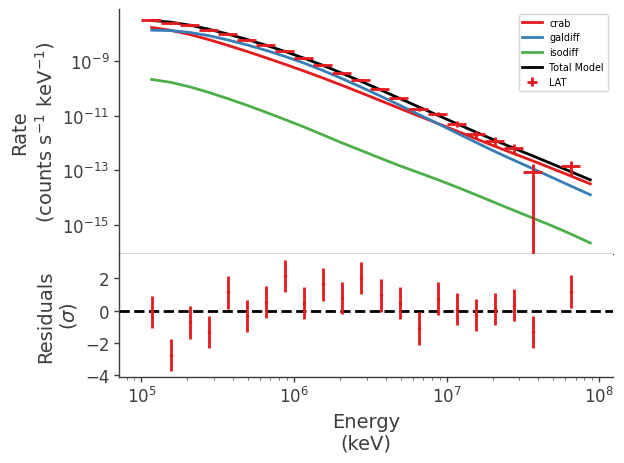

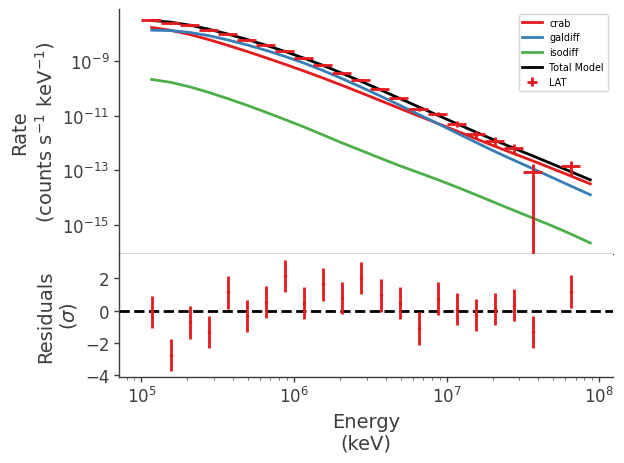

In [80]:
display_spectrum_model_counts(ba)

# Some plots

In [ ]:
fig = hawc.display_fit(smoothing_kernel_sigma=0.01, display_colorbar=True)

In [72]:
fig = hawc.display_spectrum()

NameError: name 'hawc' is not defined

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")

In [ ]:
res = jl.get_contours(
    f_model.crab.spectrum.main.Powerlaw.index, -2.5, -2, 30
)

### Disregard the work below, just for reference

In [ ]:
# Define model
spectrum = Powerlaw()
source = PointSource("crab", ra=ra_crab, dec=dec_crab, spectral_shape=spectrum)

spectrum.piv = 7 * u.TeV
spectrum.piv.fix = True

spectrum.K = 1e-14 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.bounds = (1e-35, 1e-10) / (
    u.TeV * u.cm**2 * u.s
)  # without units energies would be in keV

spectrum.alpha = -2.5  # log parabolic alpha (index)
spectrum.alpha.bounds = (-4.0, 2.0)

spectrum.beta = 0  # log parabolic beta (curvature)
spectrum.beta.bounds = (-1.0, 1.0)

model = Model(source)

model.display(complete=True)

In [ ]:
ra_crab, dec_crab = 83.633083, 22.014500

roi = HealpixConeROI(3.0, 12.0, ra=ra_crab, dec=dec_crab)

hawc = HAL("HAWC", 
                  "/home/giacomov/science/hawc/data/maptree_1024.root", 
                  "/home/giacomov/science/hawc/data/response.root",
                  roi)

hawc.set_active_measurements(1, 9)

hawc.display()